In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, cross_validate
from src.ElectricSequentialRegressor import ElectricSequentialRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score, make_scorer
import joblib
from src.Utils import mse_column_score, plot_performance_analysis, shifted_mape

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]
#NORMALIZACIÓN DE ATRIBUTOS PARA FACILITAR COMPARACIÓN ENTRE MODELOS
normalizer_X = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(normalizer_X.fit_transform(X), columns=X.columns, index=X.index)

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [4]:
random_model = ElectricSequentialRegressor(RandomForestRegressor(n_jobs=1, random_state=42), RandomForestRegressor(n_jobs=1, random_state=42))
random_grid = {
    'estimator1__n_estimators': randint(30, 101),
    'estimator1__max_depth': randint(10, 51),
    'estimator1__min_samples_split': randint(2, 21),
    'estimator1__max_features': uniform(0.1, 0.9),
    'estimator2__n_estimators': randint(80, 251),
    'estimator2__max_depth': randint(10, 51),
    'estimator2__min_samples_split': randint(2, 21),
    'estimator2__max_features': uniform(0.1, 0.9)
}
random_scoring = {
    'mse_global': 'neg_mean_squared_error',
    'mse_v_perd': make_scorer(mse_column_score, col_idx=[c for c in range(0, Y.shape[1] - 1)], greater_is_better=False),
    'mse_qgen7': make_scorer(mse_column_score, col_idx=-1, greater_is_better=False),
}
random_search = RandomizedSearchCV(random_model, random_grid, n_iter=30,
                                   cv=TimeSeriesSplit(n_splits=3), scoring=random_scoring, refit='mse_global',
                                   n_jobs=-1, verbose=2, random_state=42, return_train_score=True)

In [5]:
random_search.fit(x_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,estimator,ElectricSeque...dom_state=42))
,param_distributions,"{'estimator1__max_depth': <scipy.stats....002EADEF20750>, 'estimator1__max_features': <scipy.stats....002EADEF21350>, 'estimator1__min_samples_split': <scipy.stats....002EADEF20D50>, 'estimator1__n_estimators': <scipy.stats....002EADE20F8D0>, ...}"
,n_iter,30
,scoring,"{'mse_global': 'neg_mean_squared_error', 'mse_qgen7': make_scorer(m...', col_idx=-1), 'mse_v_perd': make_scorer(m..., 11, 12, 13])}"
,n_jobs,-1
,refit,'mse_global'
,cv,TimeSeriesSpl...est_size=None)
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [6]:
best_random_model = random_search.best_estimator_
print('MSE: ' + str(random_search.best_score_))
random_results = pd.DataFrame(random_search.cv_results_)
random_results.loc[:, ['param_estimator1__max_depth', 'param_estimator1__max_features', 'param_estimator1__min_samples_split', 'param_estimator1__n_estimators', 'param_estimator2__max_depth', 'param_estimator2__max_features', 'param_estimator2__min_samples_split', 'param_estimator2__n_estimators', 'mean_test_mse_global', 'mean_test_mse_v_perd', 'mean_test_mse_qgen7']]

MSE: -0.03642473599911371


,param_estimator1__max_depth,param_estimator1__max_features,param_estimator1__min_samples_split,param_estimator1__n_estimators,param_estimator2__max_depth,param_estimator2__max_features,param_estimator2__min_samples_split,param_estimator2__n_estimators,mean_test_mse_global,mean_test_mse_v_perd,mean_test_mse_qgen7
0,48,0.816889,16,90,30,0.240417,20,154,-0.043870,-0.046980,-0.000324
1,20,0.879559,5,53,12,0.118526,3,167,-0.056055,-0.060036,-0.000325
2,39,0.291105,2,87,31,0.106360,18,138,-0.055657,-0.059607,-0.000349
3,37,0.976380,16,91,12,0.873946,8,100,-0.045658,-0.048897,-0.000325
4,18,0.158546,5,89,23,0.827558,10,169,-0.038290,-0.040991,-0.000466
5,11,0.715810,16,89,16,0.648997,9,114,-0.038260,-0.040970,-0.000319
6,23,0.451955,19,33,11,0.482640,11,83,-0.050457,-0.054037,-0.000331
7,38,0.972626,13,63,19,0.905345,15,174,-0.039671,-0.042481,-0.000327
8,24,0.179643,9,82,33,0.421078,14,120,-0.040033,-0.042860,-0.000453
9,38,0.821977,2,100,18,0.795020,13,215,-0.038693,-0.041434,-0.000324


In [7]:
random_predictions = best_random_model.predict(x_test)
random_MAE = mean_absolute_error(y_test, random_predictions, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
random_MAPE = mean_absolute_percentage_error(y_test + 1.0, random_predictions + 1.0, multioutput='raw_values')
random_R2 = r2_score(y_test, random_predictions, multioutput='raw_values')
random_data_score = np.vstack([random_MAE, random_MAPE, random_R2])
evaluations = pd.DataFrame(random_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.003143,0.003150,0.003152,0.003152,0.003153,0.003154,0.003151,0.003151,0.003152,0.003152,0.003152,0.004337,0.004337,0.494802,0.006523
MAPE,0.001593,0.001596,0.001598,0.001598,0.001599,0.001599,0.001597,0.001598,0.001598,0.001598,0.001598,0.002192,0.002192,0.055872,0.006137
R2,0.917840,0.918995,0.919605,0.919667,0.919693,0.919745,0.919745,0.919717,0.919747,0.919791,0.919802,0.793575,0.793591,0.948355,0.883008


In [8]:
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.003333,0.494802,0.006523
MAPE,0.001689,0.055872,0.006137
R2,0.900116,0.948355,0.883008


In [9]:
joblib.dump(best_random_model, '../models/ESR_MO_RandomForest.pkl')

['../models/ESR_MO_RandomForest.pkl']

In [10]:
evaluate_model = ElectricSequentialRegressor(RandomForestRegressor(max_depth=20, min_samples_split=5, n_estimators=67, n_jobs=1, random_state=42),
                                             RandomForestRegressor(max_depth=49, max_features=0.64, min_samples_split=4, n_estimators=191, n_jobs=1, random_state=42))
evaluate_scoring = {
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error',
    'mape': make_scorer(shifted_mape, greater_is_better=False),
    'r2': 'r2'
}
evaluate_results = cross_validate(evaluate_model, X, Y, scoring=evaluate_scoring, cv=TimeSeriesSplit(n_splits=5), n_jobs=-1)
print('MSE: ' + str(-evaluate_results['test_mse'].mean()))
print('MAE: ' + str(-evaluate_results['test_mae'].mean()))
print('MAPE: ' + str(-evaluate_results['test_mape'].mean()))
print('R2: ' + str(evaluate_results['test_r2'].mean()))

MSE: 0.03745549860527614
MAE: 0.038406997982690046
MAPE: 0.005893005949524086
R2: 0.8970671090427018


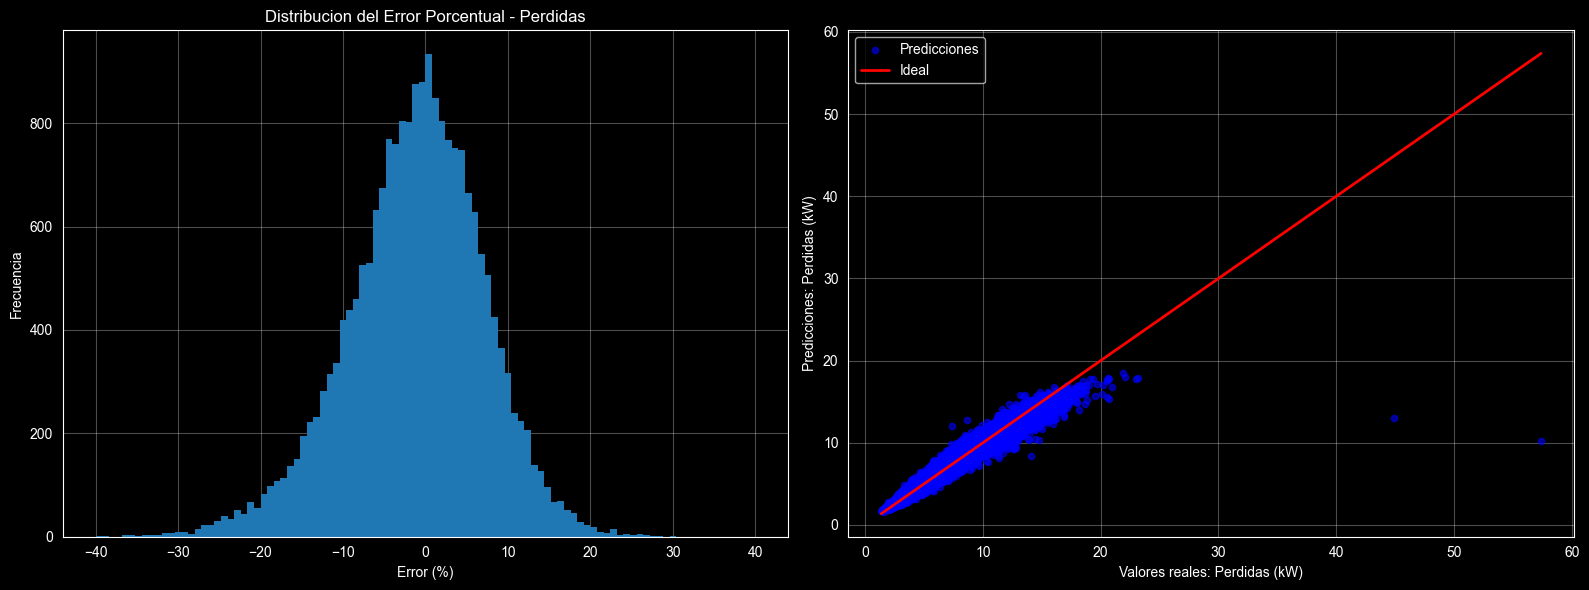

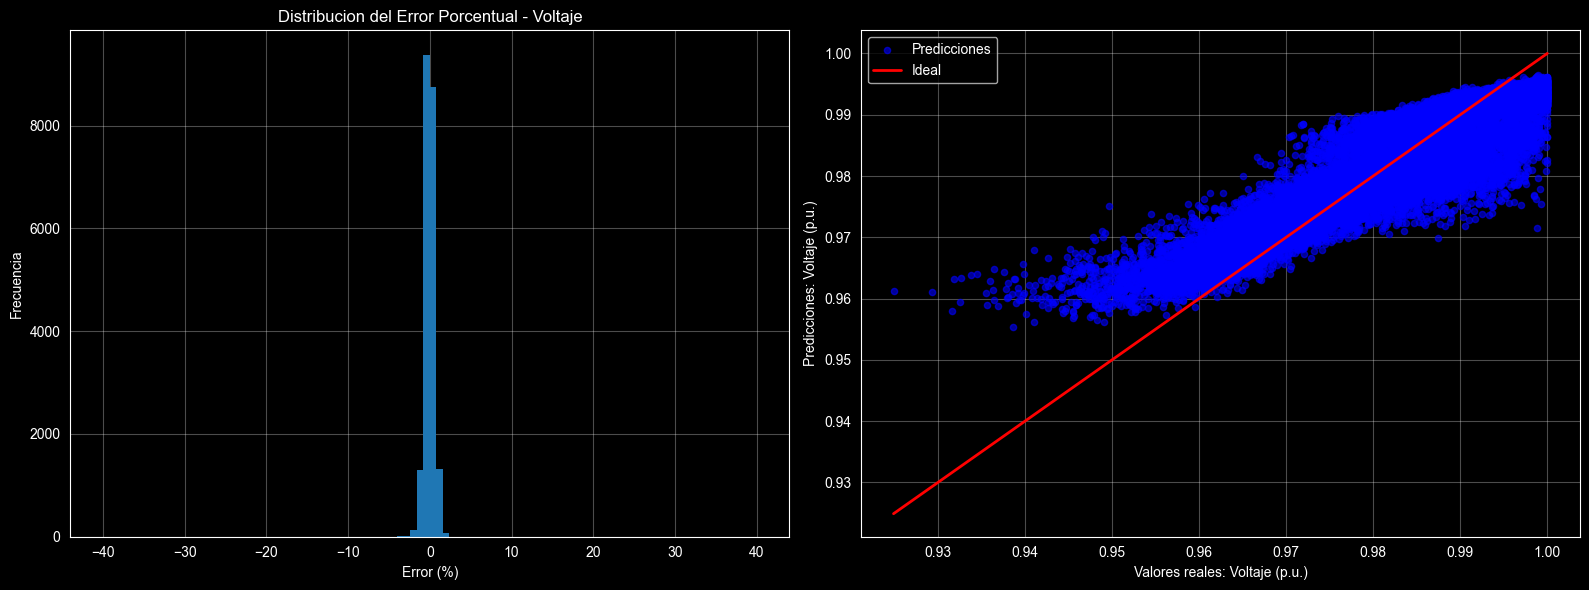

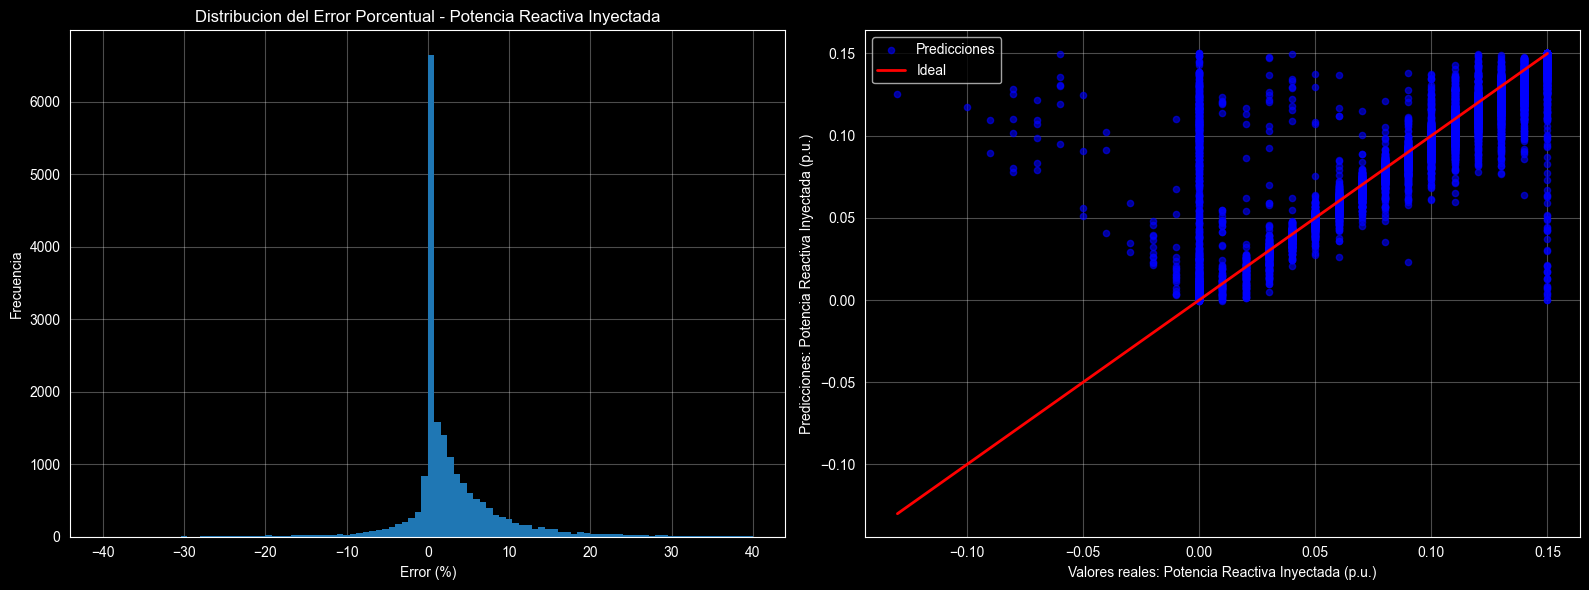

In [13]:
plot_performance_analysis(
    y_test['PERD'],
    random_predictions[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/RandomForest/ESR_MO_RandomForest_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    random_predictions[:, -4],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_MO_RandomForest_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    random_predictions[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/RandomForest/ESR_MO_RandomForest_QGen.png'
)